In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("dark_background")

# -----------------------------
# 1) Function f(x, y): two nearby Gaussians
# -----------------------------
def f(x, y):
    A1, x1, y1, s1 = 1.0,  1.0, 0.0, 0.7
    A2, x2, y2, s2 = 0.5, -1.0, 0.3, 0.4

    g1 = A1 * np.exp(-((x - x1)**2 + (y - y1)**2) / (2 * s1**2))
    g2 = A2 * np.exp(-((x - x2)**2 + (y - y2)**2) / (2 * s2**2))
    return g1 + g2

# -----------------------------------------
# 2) Numerical Hessian (and gradient if you want it)
# -----------------------------------------
def numerical_gradient(f, x0, y0, h=1e-5):
    dfdx = (f(x0 + h, y0) - f(x0 - h, y0)) / (2 * h)
    dfdy = (f(x0, y0 + h) - f(x0, y0 - h)) / (2 * h)
    return np.array([dfdx, dfdy], dtype=float)

def numerical_hessian(f, x0, y0, h=1e-4):
    f00 = f(x0, y0)

    f_xx = (f(x0 + h, y0) - 2 * f00 + f(x0 - h, y0)) / h**2
    f_yy = (f(x0, y0 + h) - 2 * f00 + f(x0, y0 - h)) / h**2

    f_xy = (
        f(x0 + h, y0 + h)
        - f(x0 + h, y0 - h)
        - f(x0 - h, y0 + h)
        + f(x0 - h, y0 - h)
    ) / (4 * h**2)

    return np.array([[f_xx, f_xy], [f_xy, f_yy]], dtype=float)

# -----------------------------
# 3) Domain + point for Hessian eigenvectors
# -----------------------------
x_min, x_max = -3.0, 3.0
y_min, y_max = -3.0, 3.0
n_grid = 180

x0, y0 = 0.8, -0.6  # point where we compute Hessian eigenvectors

# -----------------------------
# 4) Build grids
# -----------------------------
xs = np.linspace(x_min, x_max, n_grid)
ys = np.linspace(y_min, y_max, n_grid)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)

# Colormap / normalization
cmap = plt.cm.viridis
norm = plt.Normalize(Z.min(), Z.max())

# -----------------------------
# 5) Hessian eigendecomposition at (x0, y0)
# -----------------------------
f0 = f(x0, y0)
H = numerical_hessian(f, x0, y0)
evals, evecs = np.linalg.eigh(H)  # symmetric -> real eigenpairs

print("Point:", (x0, y0))
print("Hessian:\n", H)
print("Eigenvalues:", evals)
print("Eigenvectors (columns):\n", evecs)

# Visualization scale for eigenvectors in the x-y plane
vec_len = 0.9  # change length to taste

v1 = evecs[:, 0]
v2 = evecs[:, 1]

Point: (0.8, -0.6)
Hessian:
 [[-1.24592088  0.33219584]
 [ 0.33219584 -0.35994763]]
Eigenvalues: [-1.35664106 -0.24922745]
Eigenvectors (columns):
 [[-0.94869338 -0.31619752]
 [ 0.31619752 -0.94869338]]


In [2]:
# =============================
# PLOT A: 3D surface with eigenvectors at (x0, y0)
# =============================
%matplotlib qt

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X, Y, Z,
    cmap=cmap,
    norm=norm,
    linewidth=0,
    antialiased=True,
    alpha=0.6
)

# Point on the surface
ax.scatter([x0], [y0], [f0], s=70, color="white")

# Draw eigenvectors in the tangent x-y plane at z=f0 (horizontal arrows)
# (These are directions in x-y; we set dz=0 so they lie in a horizontal plane through the point.)
for v, lam in [(v1, evals[0]), (v2, evals[1])]:
    dx, dy = vec_len * v[0], vec_len * v[1]
    ax.quiver(x0, y0, 0,  dx,  dy, 0, color="red", linewidth=2, arrow_length_ratio=0.15)
    ax.quiver(x0, y0, 0, -dx, -dy, 0, color="red", linewidth=2, arrow_length_ratio=0.15)
    ax.text(x0 + dx, y0 + dy, f0, f"  λ={lam:.3g}", fontsize=10, color="white")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("3D surface with Hessian eigendirections at (x0, y0)")

ax.view_init(elev=28, azim=-55)

mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array(Z)
fig.colorbar(mappable, ax=ax, shrink=0.6, pad=0.08, label="f(x, y)")

plt.tight_layout()
plt.show()

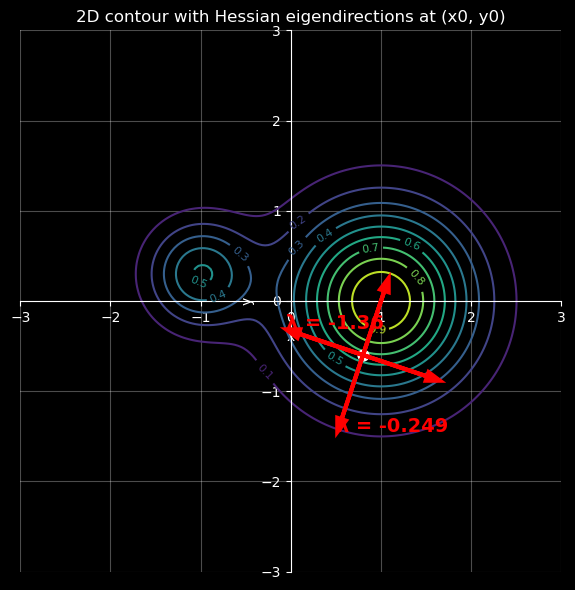

In [6]:
# =============================
# PLOT B: 2D contour (inline) with eigenvectors at (x0, y0)
# =============================
%matplotlib inline

fig2, ax2 = plt.subplots(figsize=(8, 6))

levels = 10
cs = ax2.contour(X, Y, Z, levels=levels, cmap=cmap, norm=norm)
ax2.clabel(cs, inline=True, fontsize=8)

# Expansion point
ax2.scatter([x0], [y0], color="white", s=60, zorder=5)

# Eigenvectors (thicker arrows, red)
for v, lam in [(v1, evals[0]), (v2, evals[1])]:
    dx, dy = vec_len * v[0], vec_len * v[1]
    ax2.arrow(
        x0, y0, dx, dy,
        head_width=0.10,
        linewidth=3,
        length_includes_head=True,
        color="red",
        zorder=6
    )
    ax2.arrow(
        x0, y0, -dx, -dy,
        head_width=0.10,
        linewidth=3,
        length_includes_head=True,
        color="red",
        zorder=6
    )
    ax2.text(
        x0 + dx, y0 + dy,
        f"λ = {lam:.3g}",
        fontsize=14,
        color="red",
        weight="bold",
        zorder=7
    )

# --- Center the axes spines at (0,0) ---
ax2.spines["left"].set_position("zero")
ax2.spines["bottom"].set_position("zero")
ax2.spines["right"].set_color("none")
ax2.spines["top"].set_color("none")

ax2.xaxis.set_ticks_position("bottom")
ax2.yaxis.set_ticks_position("left")

ax2.set_aspect("equal", adjustable="box")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("2D contour with Hessian eigendirections at (x0, y0)")

ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()